In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

from src.qwalk_dictionary import getOpsCirc
from src.misc import graph_matchings_parallel
from src.graphs import StaticGraph

In [2]:
def reduce_graph_space(edges, active_qubits=None):
    """
    Reduce the graph space by keeping only essential qubits.
    
    Allow merging only if:
    - Number of edges is a power of 2 (complete subcube)
    - All edges flip the SAME set of qubits
    - Variation occurs in exactly log2(num_edges) non-flipping qubits
    """
    if not edges:
        return edges, active_qubits if active_qubits is not None else []
    
    bitstring_length = len(next(iter(edges))[0])
    
    if active_qubits is None:
        active_qubits = list(range(bitstring_length))
    
    edge_list = list(edges)
    num_edges = len(edges)
    
    # Check if number of edges is a power of 2
    is_power_of_2 = (num_edges & (num_edges - 1)) == 0 and num_edges > 0
    
    # Find qubits that flip in EACH edge and check consistency
    flipping_qubits_per_edge = []
    for source, target in edge_list:
        edge_flips = set()
        for qubit_idx in active_qubits:
            pos = bitstring_length - 1 - qubit_idx
            if source[pos] != target[pos]:
                edge_flips.add(qubit_idx)
        flipping_qubits_per_edge.append(edge_flips)
    
    # Check if all edges flip the same qubits
    if not flipping_qubits_per_edge:
        return edges, active_qubits
    
    flipping_qubits = flipping_qubits_per_edge[0]
    all_same_flips = all(edge_flips == flipping_qubits for edge_flips in flipping_qubits_per_edge)
    
    if not all_same_flips:
        # Edges flip different qubits - cannot merge
        return edges, active_qubits
    
    if not flipping_qubits:
        return edges, active_qubits
    
    non_flipping_qubits = sorted(set(active_qubits) - flipping_qubits, reverse=True)
    
    from itertools import combinations
    import math
    
    # Check if edges can merge
    can_merge = False
    
    if is_power_of_2 and num_edges >= 2 and len(non_flipping_qubits) > 0:
        expected_varying_bits = int(math.log2(num_edges))
        
        if len(non_flipping_qubits) >= expected_varying_bits:
            # Check which non-flipping qubits vary
            varying_non_flipping_source = []
            varying_non_flipping_target = []
            
            for qubit_idx in non_flipping_qubits:
                pos = bitstring_length - 1 - qubit_idx
                source_values = set(source[pos] for source, target in edge_list)
                target_values = set(target[pos] for source, target in edge_list)
                
                if len(source_values) > 1:
                    varying_non_flipping_source.append(qubit_idx)
                if len(target_values) > 1:
                    varying_non_flipping_target.append(qubit_idx)
            
            # Check if both source and target vary in the same qubits
            # and exactly the expected number of qubits vary
            if (varying_non_flipping_source == varying_non_flipping_target and
                len(varying_non_flipping_source) == expected_varying_bits):
                can_merge = True
    
    if can_merge:
        # Allow merging: find minimal edges with maximal bits
        min_distinct_edges = float('inf')
        best_qubits = list(flipping_qubits)
        
        # Try all subsets
        for flip_size in range(len(flipping_qubits), 0, -1):
            for flip_subset in combinations(sorted(flipping_qubits), flip_size):
                for non_flip_size in range(len(non_flipping_qubits) + 1):
                    for non_flip_subset in combinations(sorted(non_flipping_qubits), non_flip_size):
                        test_qubits = sorted(list(flip_subset) + list(non_flip_subset))
                        test_positions = sorted([bitstring_length - 1 - q for q in test_qubits])
                        
                        test_projected = set()
                        valid_projection = True
                        
                        for source, target in edge_list:
                            source_proj = ''.join(source[pos] for pos in test_positions)
                            target_proj = ''.join(target[pos] for pos in test_positions)
                            
                            if source_proj == target_proj:
                                valid_projection = False
                                break
                            
                            if source_proj <= target_proj:
                                test_projected.add((source_proj, target_proj))
                            else:
                                test_projected.add((target_proj, source_proj))
                        
                        if valid_projection:
                            distinct_count = len(test_projected)
                            if distinct_count < min_distinct_edges:
                                min_distinct_edges = distinct_count
                                best_qubits = test_qubits
                            elif distinct_count == min_distinct_edges and len(test_qubits) > len(best_qubits):
                                best_qubits = test_qubits
    else:
        # No merging allowed: return original edges with all bits
        return edges, active_qubits
    
    qubits_to_keep = sorted(best_qubits)
    positions_to_keep = sorted([bitstring_length - 1 - q for q in qubits_to_keep])
    
    reduced_edges = set()
    for source, target in edges:
        source_proj = ''.join(source[pos] for pos in positions_to_keep)
        target_proj = ''.join(target[pos] for pos in positions_to_keep)
        
        if source_proj <= target_proj:
            reduced_edges.add((source_proj, target_proj))
        else:
            reduced_edges.add((target_proj, source_proj))
    
    return reduced_edges, qubits_to_keep

{('101', '100'), ('000', '001'), ('011', '010'), ('111', '110')}


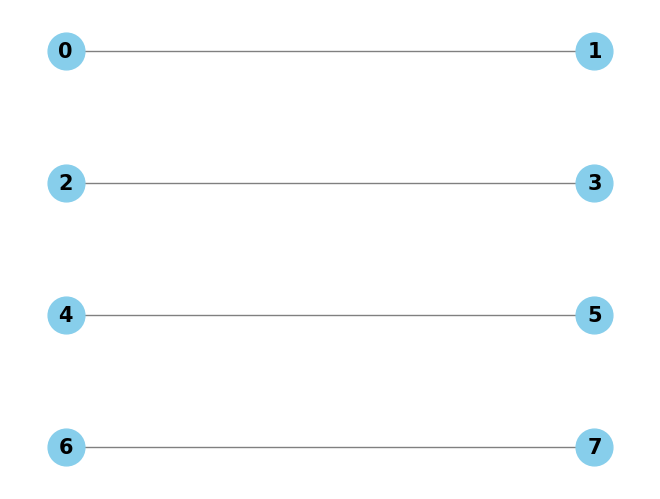

In [17]:
# edges = {('000','011'),
#           ('100', '111')}

# edges = {('00','01'),
#           ('10', '11')}

# edges = {('00','10'),
#           ('01', '11')}

# edges = {('000','001'),
#           ('010', '011')}

# edges = {('000','001'),
#           ('010', '011'),
#           ('100','101'),
#           ('110','111')}


# edges = {('000','001'),
#           ('010', '011')
#           }

matchings = [{('101', '100'), ('011', '010'), ('111', '110'), ('000', '001')}, {('101', '001'), ('000', '100')}, {('111', '010'), ('011', '100'), ('101', '110')}, {('111', '100'), ('101', '010'), ('000', '110')}, {('011', '110'), ('111', '001')}, {('011', '001'), ('000', '010')}]

edges = matchings[0]
print(edges)
G = StaticGraph(edges)
G.draw()

Reduced Edges {('0', '1')}
Reduced Space [0]


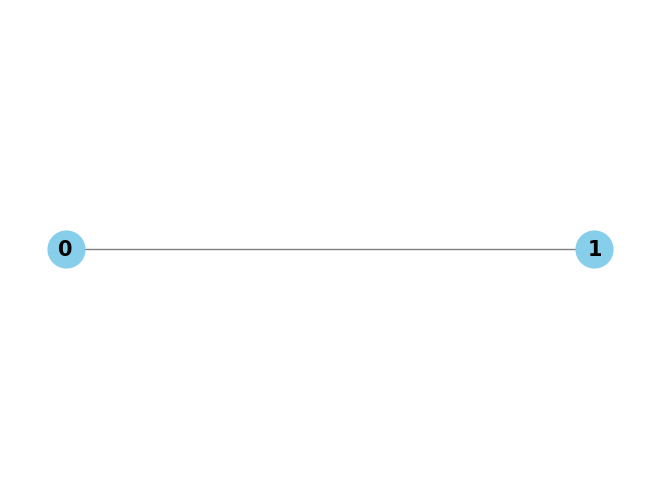

In [18]:
new_edges, new_active_qubits = reduce_graph_space(edges)
print(f'Reduced Edges {new_edges}')
print(f'Reduced Space {new_active_qubits}')
G_new = StaticGraph(new_edges)
G_new.draw()


In [5]:
def test_reduce_graph_space():
    """Test cases for reduce_graph_space function"""
    
    tests = [
        # Test 1
        {
            'edges': {('000','011'), ('100', '111')},
            'active': [0, 1, 2],
            'expected_edges': {('00', '11')},
            'expected_active': [0, 1],
            'name': 'Test 1'
        },
        # Test 2
        {
            'edges': {('00','01'), ('10', '11')},
            'active': [0, 1],
            'expected_edges': {('0', '1')},
            'expected_active': [0],
            'name': 'Test 2'
        },
        # Test 3
        {
            'edges': {('00','10'), ('01', '11')},
            'active': [0, 1],
            'expected_edges': {('0', '1')},
            'expected_active': [1],
            'name': 'Test 3'
        },
        # Test 4
        {
            'edges': {('000','001'), ('010', '011')},
            'active': [0, 1, 2],
            'expected_edges': {('00','01')},
            'expected_active': [0, 2],
            'name': 'Test 4'
        },
        {
            'edges': {('100','101'), ('110', '111')},
            'active': [0, 1, 2],
            'expected_edges': {('10','11')},
            'expected_active': [0, 2],
            'name': 'Test 5'
        },
        # Test 5
        {
            'edges': {('000','001'), ('010', '011'), ('100','101'), ('110','111')},
            'active': [0, 1, 2],
            'expected_edges': {('0', '1')},
            'expected_active': [0],
            'name': 'Test 6'
        },
        # Test 6
        {
            'edges': {('000', '001'), ('100', '101')},
            'active': [0, 1, 2],
            'expected_edges': {('00', '01')},
            'expected_active': [0, 1],
            'name': 'Test 7'
        },
        # Test 7
        {
            'edges': {('010', '011'), ('110', '111')},
            'active': [0, 1, 2],
            'expected_edges': {('10', '11')},
            'expected_active': [0, 1],
            'name': 'Test 8'
        },
        # Test 8 - Hamming distance 2, no reduction
        {
            'edges': {('000', '001'), ('110', '111')},
            'active': [0, 1, 2],
            'expected_edges': {('000', '001'), ('110', '111')},
            'expected_active': [0, 1, 2],
            'name': 'Test 9'
        },
        # Test 9 - Hamming distance 2, no reduction
        {
            'edges': {('010', '011'), ('100', '101')},
            'active': [0, 1, 2],
            'expected_edges': {('010', '011'), ('100', '101')},
            'expected_active': [0, 1, 2],
            'name': 'Test 10'
        },
        # {('0110', '1100'), ('0101', '1001')}
        {
            'edges': {('0110', '1100'), ('0101', '1001')},
            'active': [0, 1, 2, 3],
            'expected_edges': {('0110', '1100'), ('0101', '1001')},
            'expected_active': [0, 1, 2, 3],
            'name': 'Test 11'
        }
    ]
    
    passed = 0
    failed = 0
    
    for test in tests:
        result_edges, result_active = reduce_graph_space(test['edges'], test['active'])
        
        is_pass = (result_edges == test['expected_edges'] and 
                   result_active == test['expected_active'])
        
        print(f"{test['name']}:")
        print(f"  Input: edges={test['edges']}, active={test['active']}")
        print(f"  Expected: edges={test['expected_edges']}, active={test['expected_active']}")
        print(f"  Got:      edges={result_edges}, active={result_active}")
        print(f"  Pass: {is_pass}\n")
        
        if is_pass:
            passed += 1
        else:
            failed += 1
    
    print(f"Summary: {passed} passed, {failed} failed out of {len(tests)} tests")
    return passed, failed

# Run tests
test_reduce_graph_space()

Test 1:
  Input: edges={('000', '011'), ('100', '111')}, active=[0, 1, 2]
  Expected: edges={('00', '11')}, active=[0, 1]
  Got:      edges={('00', '11')}, active=[0, 1]
  Pass: True

Test 2:
  Input: edges={('10', '11'), ('00', '01')}, active=[0, 1]
  Expected: edges={('0', '1')}, active=[0]
  Got:      edges={('0', '1')}, active=[0]
  Pass: True

Test 3:
  Input: edges={('01', '11'), ('00', '10')}, active=[0, 1]
  Expected: edges={('0', '1')}, active=[1]
  Got:      edges={('0', '1')}, active=[1]
  Pass: True

Test 4:
  Input: edges={('010', '011'), ('000', '001')}, active=[0, 1, 2]
  Expected: edges={('00', '01')}, active=[0, 2]
  Got:      edges={('00', '01')}, active=[0, 2]
  Pass: True

Test 5:
  Input: edges={('110', '111'), ('100', '101')}, active=[0, 1, 2]
  Expected: edges={('10', '11')}, active=[0, 2]
  Got:      edges={('10', '11')}, active=[0, 2]
  Pass: True

Test 6:
  Input: edges={('010', '011'), ('000', '001'), ('100', '101'), ('110', '111')}, active=[0, 1, 2]
  Expect

(11, 0)